In [1]:
import pandas as pd
import numpy as np
import os
import itertools
import time
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from io import BytesIO
from scipy.stats import kstest, norm, stats, probplot
from scipy.stats import spearmanr
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, Attention, Concatenate, Input, Layer
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import Huber
from tensorflow.keras.optimizers import Adam
import shap
from tensorflow.keras.layers import Lambda
from tensorflow.keras.models import Model
from xgboost import XGBRegressor
import xgboost as xgb
from tensorflow.keras import mixed_precision
import joblib
from sklearn.inspection import permutation_importance
import matplotlib.dates as mdates

2025-10-06 05:16:33.611803: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-06 05:16:33.661810: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-06 05:16:34.485426: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.13.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [37]:
# —— 一次性设置，全局生效（期刊单栏常用字号）——
RC = {
    'font.size': 9,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'axes.unicode_minus': False
}
sns.set_style("whitegrid")     # 或 "white"
FIGSIZE = (6.8, 3.5)   # 两张图都用同一尺寸（建议）
SAVE_KW = dict(bbox_inches='tight', pad_inches=0.02)  # 两张图保存方式一致
os.makedirs("Figures", exist_ok=True)

# Data Analysis


In [4]:
df = pd.read_csv('04-24.csv')  
df['tp'] = df['tp'] * 1000
df.head(100)

,valid_time,latitude,longitude,number,expver,u10,v10,d2m,t2m,sp,tp,e,mxtpr,mntpr,tcc,ssr,lsp
0,2004-01-01 00:00:00,55.5,-10.50,0,1,15.037308,-12.340988,279.58910,282.60413,99860.06,0.138760,-0.000256,0.000067,0.000017,0.543610,3.599999e-12,0.000037
1,2004-01-01 00:00:00,55.5,-10.25,0,1,15.046097,-11.705246,279.74536,282.67834,99792.06,0.226498,-0.000238,0.000109,0.000050,0.481079,3.599999e-12,0.000031
2,2004-01-01 00:00:00,55.5,-10.00,0,1,14.989456,-10.914230,279.89380,282.75647,99740.06,0.282764,-0.000222,0.000109,0.000050,0.412537,3.599999e-12,0.000026
3,2004-01-01 00:00:00,55.5,-9.75,0,1,14.779495,-9.798019,280.01100,282.83070,99715.06,0.273705,-0.000207,0.000112,0.000050,0.329193,3.599999e-12,0.000022
4,2004-01-01 00:00:00,55.5,-9.50,0,1,14.564652,-8.629074,280.08130,282.88538,99663.06,0.273228,-0.000191,0.000112,0.000050,0.274841,3.599999e-12,0.000019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2004-01-01 00:00:00,54.5,-7.75,0,1,7.115433,1.154129,278.83130,280.31310,98243.06,0.222206,-0.000046,0.000107,0.000046,0.991638,3.599999e-12,0.000166
96,2004-01-01 00:00:00,54.5,-7.50,0,1,6.887894,1.562332,278.32544,280.11000,98385.06,0.287056,-0.000066,0.000212,0.000030,0.880158,3.599999e-12,0.000154
97,2004-01-01 00:00:00,54.5,-7.25,0,1,6.339066,2.221512,277.74146,279.69397,98385.06,0.696659,-0.000062,0.000653,0.000030,0.752350,3.599999e-12,0.000127
98,2004-01-01 00:00:00,54.5,-7.00,0,1,5.905472,2.840653,277.05200,279.26624,98420.06,0.910282,-0.000065,0.000653,0.000030,0.726990,3.599999e-12,0.000117


In [5]:
# 单独转换目标值单位
df['tp'] = df['tp'] * 1000  # m → mm

# 提取特征和目标
features = ['u10', 'v10', 'd2m', 't2m', 'sp', 'e', 'mxtpr', 'mntpr', 'tcc', 'ssr', 'lsp']
X = df[features]
y = df['tp']

# Z-score 标准化
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 保存均值与标准差以便反标准化
mean_tp = y.mean()
std_tp = y.std()
y_scaled = (y - mean_tp) / std_tp

In [6]:
df.head(100)

,valid_time,latitude,longitude,number,expver,u10,v10,d2m,t2m,sp,tp,e,mxtpr,mntpr,tcc,ssr,lsp
0,2004-01-01 00:00:00,55.5,-10.50,0,1,15.037308,-12.340988,279.58910,282.60413,99860.06,138.75961,-0.000256,0.000067,0.000017,0.543610,3.599999e-12,0.000037
1,2004-01-01 00:00:00,55.5,-10.25,0,1,15.046097,-11.705246,279.74536,282.67834,99792.06,226.49765,-0.000238,0.000109,0.000050,0.481079,3.599999e-12,0.000031
2,2004-01-01 00:00:00,55.5,-10.00,0,1,14.989456,-10.914230,279.89380,282.75647,99740.06,282.76443,-0.000222,0.000109,0.000050,0.412537,3.599999e-12,0.000026
3,2004-01-01 00:00:00,55.5,-9.75,0,1,14.779495,-9.798019,280.01100,282.83070,99715.06,273.70453,-0.000207,0.000112,0.000050,0.329193,3.599999e-12,0.000022
4,2004-01-01 00:00:00,55.5,-9.50,0,1,14.564652,-8.629074,280.08130,282.88538,99663.06,273.22770,-0.000191,0.000112,0.000050,0.274841,3.599999e-12,0.000019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2004-01-01 00:00:00,54.5,-7.75,0,1,7.115433,1.154129,278.83130,280.31310,98243.06,222.20612,-0.000046,0.000107,0.000046,0.991638,3.599999e-12,0.000166
96,2004-01-01 00:00:00,54.5,-7.50,0,1,6.887894,1.562332,278.32544,280.11000,98385.06,287.05597,-0.000066,0.000212,0.000030,0.880158,3.599999e-12,0.000154
97,2004-01-01 00:00:00,54.5,-7.25,0,1,6.339066,2.221512,277.74146,279.69397,98385.06,696.65910,-0.000062,0.000653,0.000030,0.752350,3.599999e-12,0.000127
98,2004-01-01 00:00:00,54.5,-7.00,0,1,5.905472,2.840653,277.05200,279.26624,98420.06,910.28214,-0.000065,0.000653,0.000030,0.726990,3.599999e-12,0.000117


In [7]:
# 缺失值填充
df.loc[:, 'tp'] = df['tp'].ffill()  # 前向填充
df['e'] = df['e'].interpolate() # 插值填充
df['mxtpr'] = df['mxtpr'].interpolate()
df['mntpr'] = df['mntpr'].interpolate()
df['ssr'] = df['ssr'].interpolate()
df['lsp'] = df['lsp'].interpolate()
df = df.drop(columns=['latitude', 'longitude', 'number', 'expver'])

In [49]:
# 时间处理
df['time'] = pd.to_datetime(df['valid_time'])

# 选取变量
X_vars = ['u10', 'v10', 'd2m', 't2m', 'sp', 'e', 'mxtpr', 'mntpr', 'tcc', 'ssr', 'lsp']
y_var = 'tp'

# 提取包含目标变量的数据
df_to_analyze = df[X_vars + [y_var]]  # y_var='tp'

# 计算 Spearman 相关系数矩阵
spearman_corr = df_to_analyze.corr(method='spearman')
print(spearman_corr)  # 控制台输出完整矩阵（包含 tp）

# 假设已定义 RC / FIGSIZE / SAVE_KW，并已 import seaborn as sns, matplotlib.pyplot as plt

with plt.rc_context(RC):
    # 若想与其它图同宽，但做成正方形画布：用同样宽度的方形尺寸
    FIGSIZE_SQUARE = (FIGSIZE[0], FIGSIZE[0])   # 例如 (6.8, 6.8)

    fig, ax = plt.subplots(figsize=FIGSIZE_SQUARE)

    sns.heatmap(
        spearman_corr,
        cmap=sns.color_palette("Blues", as_cmap=True),  # 纯蓝渐变
        annot=True, fmt=".2f",
        annot_kws={"size": RC['font.size']},
        vmin=-1, vmax=1,
        linewidths=0,               # 无白框
        square=True,                # 单元格正方形（1:1）
        cbar_kws={"label": "Spearman $\\rho$", "shrink": 0.8, "pad": 0.02},
        ax=ax
    )

    # 去掉轴外框
    for sp in ax.spines.values():
        sp.set_visible(False)

    ax.set_title("Spearman Correlation Heatmap")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

    fig.tight_layout()
    fig.savefig("Figures/Spearman_heatmap_blue_square.pdf", **SAVE_KW)
    fig.savefig("Figures/Spearman_heatmap_blue_square.png", dpi=300, **SAVE_KW)
    plt.close(fig)


            u10       v10       d2m       t2m        sp         e     mxtpr  \
u10    1.000000  0.029994  0.146848  0.155772 -0.169415 -0.144084  0.260578   
v10    0.029994  1.000000  0.278009  0.178245 -0.155448  0.162162  0.143239   
d2m    0.146848  0.278009  1.000000  0.883302  0.035833  0.128974  0.172420   
t2m    0.155772  0.178245  0.883302  1.000000  0.081985 -0.192470  0.088943   
sp    -0.169415 -0.155448  0.035833  0.081985  1.000000  0.075281 -0.351527   
e     -0.144084  0.162162  0.128974 -0.192470  0.075281  1.000000 -0.185452   
mxtpr  0.260578  0.143239  0.172420  0.088943 -0.351527 -0.185452  1.000000   
mntpr  0.226454  0.152108  0.170206  0.034440 -0.332330 -0.081652  0.867250   
tcc   -0.036918  0.279313  0.267318  0.167782 -0.092624  0.092366  0.315777   
ssr    0.029137 -0.072580  0.220583  0.427268  0.074491 -0.463523 -0.006957   
lsp    0.201896  0.201942  0.221691  0.036998 -0.319926  0.044200  0.815905   
tp     0.269093  0.140628  0.173748  0.095842 -0.368

In [9]:
# 时间格式转换
df['time'] = pd.to_datetime(df['valid_time'])

# 筛选后的变量（根据 Spearman 相关性和物理意义）
X_vars = ['mxtpr', 'mntpr', 'lsp', 'tcc', 'v10', 'u10', 'd2m']  # 输入特征
y_var = 'tp'  # 预测目标

# 提取变量
X = df[X_vars].values
y = df[[y_var]].values

# 标准化
from sklearn.preprocessing import StandardScaler
scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_x.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# 构造时间序列格式（6小时窗口）
def create_sequences(X, y, window_size=6):
    Xs, ys = [], []
    for i in range(len(X) - window_size):
        Xs.append(X[i:i+window_size])
        ys.append(y[i+window_size])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, window_size=6)

# 划分训练集和测试集
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, shuffle=False)


In [10]:
# 数据 reshape（如果你每个时间步是多特征输入）
# 输入维度: (samples, timesteps, features)
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

In [11]:
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def call(self, inputs):
        query, value = inputs, inputs
        score = tf.matmul(query, value, transpose_b=True)
        weights = tf.nn.softmax(score, axis=-1)
        context = tf.matmul(weights, value)
        return context


In [12]:
timesteps = X_train.shape[1]
features = X_train.shape[2]

inputs = Input(shape=(timesteps, features))

# 第一层 BiLSTM
x = Bidirectional(LSTM(64, return_sequences=True))(inputs)
x = Dropout(0.2)(x)

# 第二层 BiLSTM
x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = Dropout(0.2)(x)

# 第三层 BiLSTM
x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = Dropout(0.2)(x)

# Attention
attention = AttentionLayer()(x)
attention = Lambda(lambda x: tf.reduce_mean(x, axis=1))(attention)

# 输出均值和方差
mean_output = Dense(1, name='mean_output')(attention)
log_var_output = Dense(1, name='log_var_output')(attention)

# 输出模型
model = Model(inputs=inputs, outputs=[mean_output, log_var_output])

2025-10-06 05:16:40.866308: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22290 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:16:00.0, compute capability: 8.9


In [13]:
def nll_loss(y_true, y_pred_mean, y_pred_log_var):
    y_true = tf.cast(y_true, tf.float32)
    precision = tf.exp(-y_pred_log_var)
    return tf.reduce_mean(0.5 * precision * tf.square(y_true - y_pred_mean) + 0.5 * y_pred_log_var)

In [14]:
# 自定义模型类
class CustomNLLModel(tf.keras.Model):
    def __init__(self, model, **kwargs):
        super().__init__(**kwargs)
        self.model = model  # 这是 Functional API 构建的模型

    def call(self, inputs, training=False):
        return self.model(inputs, training=training)

    @tf.function
    def train_step(self, data):
        x, y = data
        with tf.GradientTape() as tape:
            y_pred_mean, y_pred_log_var = self(x, training=True)
            loss = nll_loss(y, y_pred_mean, y_pred_log_var)

        gradients = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_variables))
        self.compiled_metrics.update_state(y, y_pred_mean)
        return {"loss": loss}

    @tf.function
    def test_step(self, data):
        x, y = data
        y_pred_mean, y_pred_log_var = self(x, training=False)
        loss = nll_loss(y, y_pred_mean, y_pred_log_var)
        self.compiled_metrics.update_state(y, y_pred_mean)
        return {"loss": loss}

# 用你构建好的 mean 和 log_var 模型输出构建一个基础模型
base_model = Model(inputs=inputs, outputs=[mean_output, log_var_output])

# 1. 定义学习率衰减
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=2000,
    decay_rate=0.96,
    staircase=True
)

# 2. 基础优化器
base_optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

# 3. 混合精度优化器（防止精度溢出）
optimizer = mixed_precision.LossScaleOptimizer(base_optimizer)

# 包装成自定义训练模型
nll_model = CustomNLLModel(base_model)
nll_model.compile(optimizer=optimizer, run_eagerly=False)  # 注意：这里不提供 loss

In [15]:
# Step 1: 手动划分训练集和验证集
val_split = int(len(X_train) * 0.8)
X_tr, X_val = X_train[:val_split], X_train[val_split:]
y_tr, y_val = y_train[:val_split], y_train[val_split:]

# Step 2: 构建 tf.data.Dataset 管道（训练集和验证集）
train_ds = tf.data.Dataset.from_tensor_slices((X_tr, y_tr)) \
                          .shuffle(buffer_size=10000) \
                          .batch(64) \
                          .prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)) \
                        .batch(64) \
                        .prefetch(tf.data.AUTOTUNE)

early_stop = EarlyStopping(
    monitor='val_loss',       # 根据验证集损失监控
    patience=10,              # 若10个epoch没有提升就停止
    restore_best_weights=True  # 恢复最优模型参数
)

# Step 3: 使用新的 dataset 来训练模型
history = nll_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
    with tf.GradientTape() as tape:
      loss = loss_fn()
      scaled_loss = opt.get_scaled_loss(loss)
    scaled_grads = tape.gradient(scaled_loss, vars)
    grads = opt.get_unscaled_gradients(scaled_grads)
    opt.apply_gradients([(grads, var)])
For more information, see https://www.tensorflow.org/api_docs/python/tf/keras/mixed_precision/LossScaleOptimizer
    with tf.GradientTape() as tape:
      loss = loss_fn()
      scaled_loss = opt.get_scaled_loss(loss)
    scaled_grads = tape.gradient(scaled_loss, vars)
    grads = opt.get_unscaled_gradients(scaled_grads)
    opt.apply_gradients([(grads, var)])
For more information, see https://www.tensorflow.org/api_docs/python/tf/keras/mixed_precision/LossScaleOptimizer


2025-10-06 05:16:49.711462: W tensorflow/core/grappler/costs/op_level_cost_estimator.cc:693] Error in PredictCost() for the op: op: "Softmax" attr { key: "T" value { type: DT_FLOAT } } inputs { dtype: DT_FLOAT shape { unknown_rank: true } } device { type: "GPU" vendor: "NVIDIA" model: "NVIDIA GeForce RTX 4090" frequency: 2520 num_cores: 128 environment { key: "architecture" value: "8.9" } environment { key: "cuda" value: "11080" } environment { key: "cudnn" value: "8600" } num_registers: 65536 l1_cache_size: 24576 l2_cache_size: 75497472 shared_memory_size_per_multiprocessor: 102400 memory_size: 23373479936 bandwidth: 1008096000 } outputs { dtype: DT_FLOAT shape { unknown_rank: true } }
2025-10-06 05:16:50.385516: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600
2025-10-06 05:16:50.547455: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
202

2914/2918 [============================>.] - ETA: 0s - loss: -0.7762

2025-10-06 05:17:25.906794: W tensorflow/core/grappler/costs/op_level_cost_estimator.cc:693] Error in PredictCost() for the op: op: "Softmax" attr { key: "T" value { type: DT_FLOAT } } inputs { dtype: DT_FLOAT shape { unknown_rank: true } } device { type: "GPU" vendor: "NVIDIA" model: "NVIDIA GeForce RTX 4090" frequency: 2520 num_cores: 128 environment { key: "architecture" value: "8.9" } environment { key: "cuda" value: "11080" } environment { key: "cudnn" value: "8600" } num_registers: 65536 l1_cache_size: 24576 l2_cache_size: 75497472 shared_memory_size_per_multiprocessor: 102400 memory_size: 23373479936 bandwidth: 1008096000 } outputs { dtype: DT_FLOAT shape { unknown_rank: true } }


2918/2918 [==============================] - 46s 12ms/step - loss: -0.7769 - val_loss: -1.8759
Epoch 2/50
2918/2918 [==============================] - 33s 11ms/step - loss: -0.9930 - val_loss: -1.6813
Epoch 3/50
2918/2918 [==============================] - 33s 11ms/step - loss: -0.9843 - val_loss: -1.3662
Epoch 4/50
2918/2918 [==============================] - 33s 11ms/step - loss: -1.0899 - val_loss: -1.6083
Epoch 5/50
2918/2918 [==============================] - 33s 11ms/step - loss: -1.0454 - val_loss: -1.9267
Epoch 6/50
2918/2918 [==============================] - 34s 12ms/step - loss: -1.1453 - val_loss: -1.6646
Epoch 7/50
2918/2918 [==============================] - 33s 11ms/step - loss: -1.1632 - val_loss: -1.6518
Epoch 8/50
2918/2918 [==============================] - 33s 11ms/step - loss: -1.1966 - val_loss: -1.7625
Epoch 9/50
2918/2918 [==============================] - 34s 12ms/step - loss: -1.2271 - val_loss: -1.2465
Epoch 10/50
2918/2918 [==============================] - 

In [39]:
# === Step 1: 预测（必须解包） ===
y_pred_mean, y_pred_log_var = nll_model.predict(X_val)
y_pred = y_pred_mean  # ✅ 使用均值作为预测值

# === Step 2: 可视化前处理 ===
# 保证是 numpy 数组
y_pred = np.array(y_pred)
y_val = np.array(y_val)

# 如果是三维的，取最后一个时间步
if y_pred.ndim == 3:
    y_pred = y_pred[:, -1, :]
if y_val.ndim == 3:
    y_val = y_val[:, -1, :]

# reshape 成二维
y_val = y_val.reshape(-1, 1)
y_pred = y_pred.reshape(-1, 1)

# 截断为相同长度
min_len = min(len(y_val), len(y_pred))
y_val = y_val[:min_len]
y_pred = y_pred[:min_len]

# 反标准化
y_val_inv = scaler_y.inverse_transform(y_val)
y_pred_inv = scaler_y.inverse_transform(y_pred)

# ---------- 构造时间轴 ----------
N = len(y_pred_inv)  # 与绘图数据一致
time_axis = None

try:
    # 1) 如果 X_val 有 DatetimeIndex
    if hasattr(X_val, 'index') and isinstance(X_val.index, pd.DatetimeIndex):
        time_axis = X_val.index[:N]
    # 2) 如果 X_val 有 'time' 列
    elif hasattr(X_val, 'columns') and ('time' in X_val.columns):
        time_axis = pd.to_datetime(X_val['time'].iloc[:N])
except Exception:
    pass

# 3) 兜底：用原始 df 的时间（取最后 N 个，假设已按时间排序）
if time_axis is None:
    time_axis = pd.to_datetime(df['time'].iloc[-N:])

# ---------- 可视化（时间刻度） ----------
with plt.rc_context(RC):
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.plot(time_axis, y_val_inv.ravel(),  label='True Values', color='blue', alpha=0.7)
    ax.plot(time_axis, y_pred_inv.ravel(), label='Predictions', color='red', ls='--', alpha=0.7)

    ax.set_xlabel('Time')
    ax.set_ylabel('Target (original scale)')
    ax.set_title('True vs Predicted')
    ax.legend()
    ax.grid(True, ls='--', lw=0.5, alpha=0.7)

    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=30, ha='right')

    fig.tight_layout()
    fig.savefig('Figures/true_vs_pred_time_fixed.pdf', **SAVE_KW)
    fig.savefig('Figures/true_vs_pred_time_fixed.png', dpi=300, **SAVE_KW)
    plt.close(fig)

1459/1459 [==============================] - 5s 3ms/step


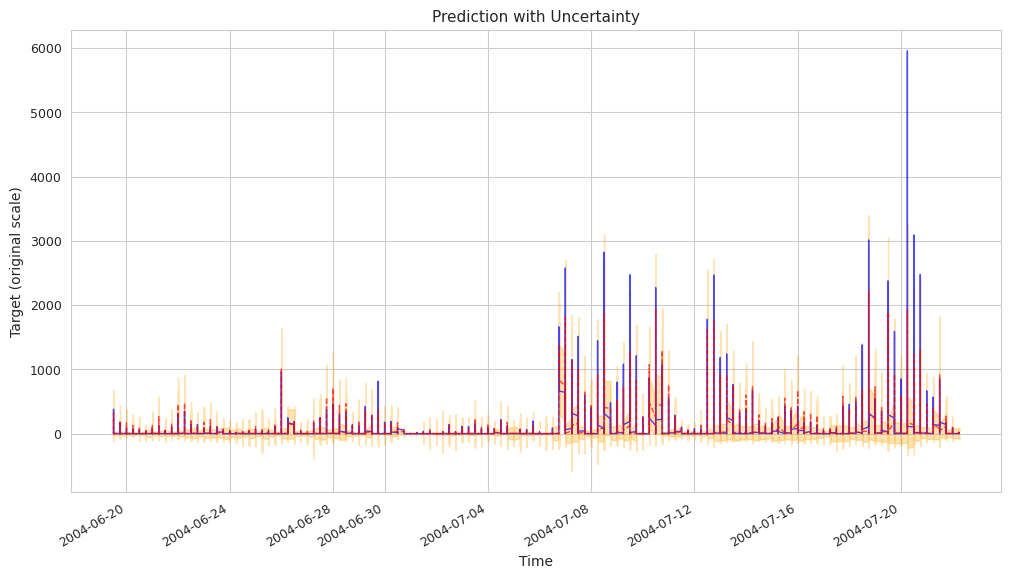

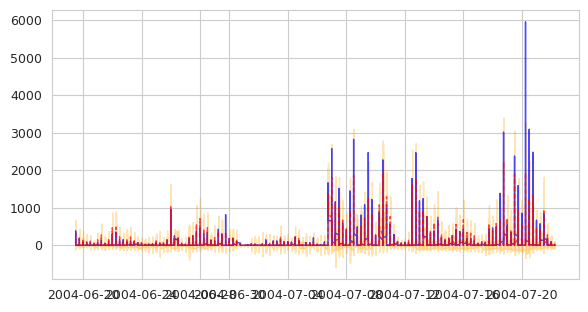

In [40]:
# === 1) 反标准化 std（与 y_pred_inv 的单位一致） ===
std_pred = np.sqrt(np.exp(y_pred_log_var)).reshape(-1, 1)   # (N,1)
# 若用 StandardScaler，对标准差需乘回 scale_
if hasattr(scaler_y, 'scale_'):
    std_pred = std_pred * float(np.ravel(scaler_y.scale_)[0])

# 与 y_pred_inv 对齐长度
N = len(y_pred_inv)
std_pred = std_pred[:N]

# === 2) 构造时间轴（优先用 X_val 的索引/列；否则退化到 df['time']） ===
time_axis = None
try:
    if hasattr(X_val, 'index') and isinstance(X_val.index, pd.DatetimeIndex):
        time_axis = X_val.index[:N]
    elif hasattr(X_val, 'columns') and ('time' in X_val.columns):
        time_axis = pd.to_datetime(X_val['time'].iloc[:N])
except Exception:
    pass
if time_axis is None:
    time_axis = pd.to_datetime(df['time'].iloc[-N:])   # 退化方案：用原 df 末 N 个时间

# === 3) 画图（时间横轴 + 95% CI） ===
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(time_axis, y_val_inv.ravel(), label='True Values', color='blue', alpha=0.7)
ax.plot(time_axis, y_pred_inv.ravel(), label='Predictions', color='red', linestyle='--', alpha=0.7)

# 95% 置信区间
lower = y_pred_inv.ravel() - 1.96 * std_pred.ravel()
upper = y_pred_inv.ravel() + 1.96 * std_pred.ravel()
ax.fill_between(time_axis, lower, upper, color='orange', alpha=0.30, label='95% Confidence Interval')

ax.set_xlabel('Time')
ax.set_ylabel('Target (original scale)')
ax.set_title('Prediction with Uncertainty')

# 时间刻度美化
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=30, ha='right')


import os
os.makedirs("Figures", exist_ok=True)

fig, ax = plt.subplots(figsize=FIGSIZE)

# 主曲线
ax.plot(time_axis, y_val_inv.ravel(),  label='True Values',  color='blue', alpha=0.7)
ax.plot(time_axis, y_pred_inv.ravel(), label='Predictions', color='red',  linestyle='--', alpha=0.7)

# 95% CI
lower = y_pred_inv.ravel() - 1.96 * std_pred.ravel()
upper = y_pred_inv.ravel() + 1.96 * std_pred.ravel()
ax.fill_between(time_axis, lower, upper, color='orange', alpha=0.30, label='95% Confidence Interval')

with plt.rc_context(RC):
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.plot(time_axis, y_val_inv.ravel(),  label='True Values', color='blue', alpha=0.7)
    ax.plot(time_axis, y_pred_inv.ravel(), label='Predictions', color='red', ls='--', alpha=0.7)

    lower = y_pred_inv.ravel() - 1.96*std_pred.ravel()
    upper = y_pred_inv.ravel() + 1.96*std_pred.ravel()
    ax.fill_between(time_axis, lower, upper, color='orange', alpha=0.30, label='95% Confidence Interval')

    ax.set_xlabel('Time')
    ax.set_ylabel('Target (original scale)')
    ax.set_title('Prediction with Uncertainty')
    ax.legend()
    ax.grid(True, ls='--', lw=0.5, alpha=0.7)

    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=30, ha='right')

    fig.tight_layout()
    fig.savefig('Figures/pred_with_uncertainty_time.pdf', **SAVE_KW)
    fig.savefig('Figures/pred_with_uncertainty_time.png', dpi=300, **SAVE_KW)
    plt.close(fig)


In [41]:
# === 预测三组数据（输出均值和 log 方差） ===
y_pred_mean_train, _ = nll_model.predict(X_tr)
y_pred_mean_val, _ = nll_model.predict(X_val)
y_pred_mean_test, y_pred_log_var = nll_model.predict(X_test)

1824/1824 [==============================] - 6s 3ms/step


In [42]:
# === 反标准化并除以 1000（从 mm 恢复为 m） ===
y_tr_inv = scaler_y.inverse_transform(y_tr.reshape(-1, 1)).flatten() / 1000
y_val_inv = scaler_y.inverse_transform(y_val.reshape(-1, 1)).flatten() / 1000
y_test_inv = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten() / 1000

y_pred_train_inv = scaler_y.inverse_transform(y_pred_mean_train.reshape(-1, 1)).flatten() / 1000
y_pred_val_inv = scaler_y.inverse_transform(y_pred_mean_val.reshape(-1, 1)).flatten() / 1000
y_pred_test_inv = scaler_y.inverse_transform(y_pred_mean_test.reshape(-1, 1)).flatten() / 1000

def evaluate_metrics(y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2 = r2_score(y_true, y_pred)
    return rmse, r2

train_rmse, train_r2 = evaluate_metrics(y_tr_inv, y_pred_train_inv)
val_rmse, val_r2 = evaluate_metrics(y_val_inv, y_pred_val_inv)
test_rmse, test_r2 = evaluate_metrics(y_test_inv, y_pred_test_inv)
print(f"Train RMSE: {train_rmse:.4f} \tR²: {train_r2:.4f}")
print(f"Val   RMSE: {val_rmse:.4f} \tR²: {val_r2:.4f}")
print(f"Test  RMSE: {test_rmse:.4f} \tR²: {test_r2:.4f}")

Train RMSE: 0.1422 	R²: 0.7949
Val   RMSE: 0.1032 	R²: 0.6580
Test  RMSE: 0.1623 	R²: 0.7449


In [45]:
# 1. 只提取预测均值子模型
mean_model = tf.keras.Model(inputs=nll_model.model.input, outputs=nll_model.model.outputs[0])

# 2. 准备背景数据（建议用几条数据）
background = X_val[:50]      # 作为 baseline
X_explain = X_val[:100]      # 待解释样本

# 3. 构建 GradientExplainer
explainer = shap.GradientExplainer(mean_model, background)

# 4. 计算 SHAP 值
shap_values = explainer.shap_values(X_explain)  # 输出 shape: (samples, 6, 7)

# 1. 取出 shap_values 的数组部分
shap_values_arr = shap_values[0]  # 取第一个目标输出的 SHAP 值

# 2. 展平成 2D
shap_values_2d = shap_values_arr.reshape(shap_values_arr.shape[0], -1)
X_explain_2d = X_explain.reshape(X_explain.shape[0], -1)

# 生成 feature_names
var_names = ['t2m', 'd2m', 'sp', 'u10', 'v10', 'e', 'tcc']  # 你实际的 7 个变量名
timesteps = 6

feature_names = []
for t in range(timesteps):
    for v in var_names:
        feature_names.append(f"{v}@t-{timesteps - 1 - t}")  # 从旧到新

# 假设已定义 RC / FIGSIZE / SAVE_KW，并已 import shap, plt
with plt.rc_context(RC):
    shap.summary_plot(
        shap_values_2d,
        X_explain_2d,
        feature_names=feature_names,
        show=False,
        plot_size=FIGSIZE,     # 先给 SHAP 一个目标尺寸
        color_bar=True
    )

    fig = plt.gcf()
    fig.set_size_inches(*FIGSIZE)     # 双保险，确保尺寸一致

    # --- 统一所有轴的字号（SHAP会创建多个axes，包括colorbar）---
    axes = fig.axes
    if len(axes) > 0:
        main_ax = axes[0]
        # x/y 轴标题 & 刻度
        main_ax.xaxis.label.set_size(RC['axes.labelsize'])
        main_ax.yaxis.label.set_size(RC['axes.labelsize'])
        main_ax.tick_params(axis='x', labelsize=RC['xtick.labelsize'])
        main_ax.tick_params(axis='y', labelsize=RC['ytick.labelsize'])
        for t in main_ax.get_yticklabels():
            t.set_fontsize(RC['ytick.labelsize'])

    # colorbar 一般是最后一个轴
    if len(axes) >= 2:
        cbar_ax = axes[-1]
        cbar_ax.tick_params(labelsize=RC['xtick.labelsize'])
        cbar_ax.yaxis.label.set_size(RC['axes.labelsize'])

    fig.tight_layout()
    fig.savefig('Figures/shap_feature.pdf', **SAVE_KW)            # 矢量
    fig.savefig('Figures/shap_feature.png', dpi=300, **SAVE_KW)    # 预览
    plt.close(fig)


`tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.
2025-10-06 09:40:01.316071: W tensorflow/core/grappler/costs/op_level_cost_estimator.cc:693] Error in PredictCost() for the op: op: "Softmax" attr { key: "T" value { type: DT_FLOAT } } inputs { dtype: DT_FLOAT shape { unknown_rank: true } } device { type: "GPU" vendor: "NVIDIA" model: "NVIDIA GeForce RTX 4090" frequency: 2520 num_cores: 128 environment { key: "architecture" value: "8.9" } environment { key: "cuda" value: "11080" } environment { key: "cudnn" value: "8600" } num_registers: 65536 l1_cache_size: 24576 l2_cache_size: 75497472 shared_memory_size_per_multiprocessor: 102400 memory_size: 23373479936 bandwidth: 1008096000 } outputs { dtype: DT_FLOAT shape { unknown_rank: true } }


In [46]:
# 假设你已有的变量
var_names = ['t2m', 'd2m', 'sp', 'u10', 'v10', 'e', 'tcc']
timesteps = 6

# 计算平均 |SHAP|（保持你原来的做法）
shap_var_mean = np.abs(shap_values_arr).mean(axis=(0, 1))  # (7,)

# 可选：按重要性降序显示更清晰（不想排序就删掉这个块）
order = np.argsort(shap_var_mean)
var_names_plot = [var_names[i] for i in order]
shap_mean_plot = shap_var_mean[order]

with plt.rc_context(RC):
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.barh(var_names_plot, shap_mean_plot)
    ax.set_xlabel('Mean |SHAP|')
    ax.set_title('Average Feature Importance by Variable')
    ax.grid(True, axis='x', linestyle='--', linewidth=0.5, alpha=0.7)

    fig.tight_layout()
    fig.savefig('Figures/shap_bar_by_variable.pdf', **SAVE_KW)          # 矢量
    fig.savefig('Figures/shap_bar_by_variable.png', dpi=300, **SAVE_KW) # 预览
    plt.close(fig)

print("已保存：Figures/shap_bar_by_variable.[pdf|png]")

已保存：Figures/shap_bar_by_variable.[pdf|png]


In [47]:
# 平均绝对 SHAP 值（|SHAP| 表示重要性）
mean_abs_shap = np.abs(shap_values_2d).mean(axis=0)  # shape: (42,)
mean_abs_shap = mean_abs_shap.reshape((6, 7))        # shape: (time_step, variable)

# 构建 DataFrame，便于画图
var_names = ['t2m', 'd2m', 'sp', 'u10', 'v10', 'e', 'tcc']
timesteps = [f"t-{i}" for i in range(5, -1, -1)]  # 从 t-5 到 t-0
shap_df = pd.DataFrame(mean_abs_shap, index=timesteps, columns=var_names)

# --- 画热图（与前两张图一致的版式） ---
with plt.rc_context(RC):
    fig, ax = plt.subplots(figsize=FIGSIZE)

    sns.heatmap(
        shap_df,                  # 6×7 的 DataFrame（index: t-5..t-0, columns: var names）
        cmap="YlGnBu",
        annot=True, fmt=".3f",
        annot_kws={"size": RC['font.size']},  # 注释字号跟随全局
        cbar_kws={"label": "Mean |SHAP|", "shrink": 0.8, "pad": 0.02},
        ax=ax
    )

    ax.set_title("SHAP Feature Importance across Time Steps")
    ax.set_xlabel("Variable")
    ax.set_ylabel("Time Step")
    # x 轴标签角度与之前一致
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

    fig.tight_layout()
    fig.savefig("Figures/shap_time_variable_heatmap.pdf", **SAVE_KW)           # 矢量
    fig.savefig("Figures/shap_time_variable_heatmap.png", dpi=300, **SAVE_KW)  # 预览
    plt.close(fig)

# XGBoost

In [21]:
# 将 3D 输入 [samples, 6, 7] 展平成 [samples, 42]，适用于 XGBoost
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)
y_train_flat = y_train.reshape(-1)
y_test_flat = y_test.reshape(-1)

In [65]:
# 定义回归模型
xgb_model = xgb.XGBRegressor(
    n_estimators=100,  # 树数量
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# 模型训练
xgb_model.fit(X_train_flat, y_train_flat)

# 模型预测
y_pred_train = xgb_model.predict(X_train_flat)
y_pred_test = xgb_model.predict(X_test_flat)

# 反标准化并转换单位为米（/1000）
y_train_inv = scaler_y.inverse_transform(y_train_flat.reshape(-1, 1)).flatten() / 1000
y_test_inv = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten() / 1000
y_pred_train_inv = scaler_y.inverse_transform(y_pred_train.reshape(-1, 1)).flatten() / 1000
y_pred_test_inv = scaler_y.inverse_transform(y_pred_test.reshape(-1, 1)).flatten() / 1000

# 计算评估指标
from sklearn.metrics import mean_squared_error, r2_score

def evaluate_metrics(y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2 = r2_score(y_true, y_pred)
    return rmse, r2

# 输出 Train 和 Test 的 RMSE 和 R²
train_rmse, train_r2 = evaluate_metrics(y_train_inv, y_pred_train_inv)
test_rmse, test_r2 = evaluate_metrics(y_test_inv, y_pred_test_inv)

print(f"XGBoost Train RMSE: {train_rmse:.4f} \tR²: {train_r2:.4f}")
print(f"XGBoost Test  RMSE: {test_rmse:.4f} \tR²: {test_r2:.4f}")


XGBoost Train RMSE: 0.1171 	R²: 0.8405
XGBoost Test  RMSE: 0.1601 	R²: 0.7516


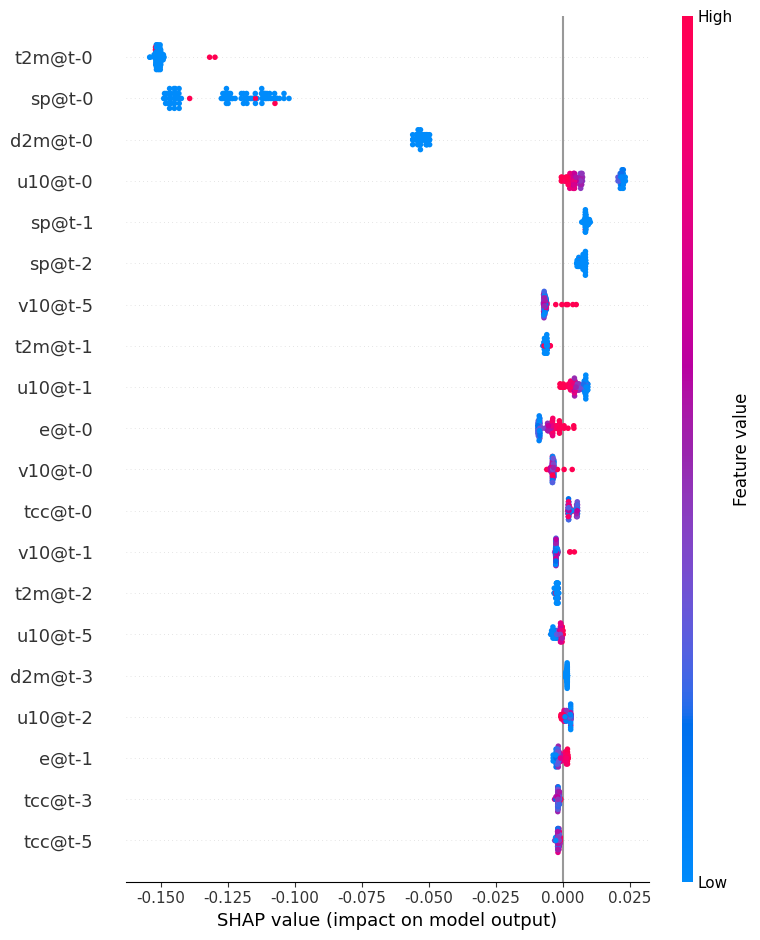

In [31]:
import shap
import matplotlib.pyplot as plt

# 构建 SHAP explainer
explainer = shap.Explainer(xgb_model, X_train_flat)

# 选取部分测试集样本进行解释
X_explain = X_test_flat[:100]
shap_values = explainer(X_explain)

# 生成 feature names（与 BU-LSTM 一致）
var_names = ['t2m', 'd2m', 'sp', 'u10', 'v10', 'e', 'tcc']
timesteps = 6
feature_names = [f"{v}@t-{timesteps - 1 - t}" for t in range(timesteps) for v in var_names]

# SHAP summary plot
shap.summary_plot(shap_values.values, X_explain, feature_names=feature_names, show=False)
plt.savefig("xgboost_shap_summary.png", dpi=300, bbox_inches='tight')
plt.show()

# BU-LSTM

In [11]:
# 构建模型
model = Sequential()
model.add(Bidirectional(LSTM(50, return_sequences=True), input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.3))
model.add(Bidirectional(LSTM(50)))
model.add(Dropout(0.3))
model.add(Dense(2))  # 输出两个值：均值和 log 方差（可用于不确定性估计）

# 自定义负对数似然损失函数（NLL）
def nll_gaussian(y_true, y_pred):
    mean = y_pred[:, 0]
    log_var = y_pred[:, 1]
    precision = tf.exp(-log_var)
    return tf.reduce_mean(0.5 * tf.math.log(2 * np.pi) + 0.5 * log_var +
                          0.5 * precision * tf.square(y_true[:, 0] - mean))

model.compile(optimizer=Adam(0.001), loss=nll_gaussian)

# 设置 early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 模型训练
history = model.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=64, callbacks=[early_stop])

# 模型评估与预测
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# 分离均值和方差
y_train_mean = y_train_pred[:, 0]
y_test_mean = y_test_pred[:, 0]
y_train_var = np.exp(y_train_pred[:, 1])  # 方差
y_test_var = np.exp(y_test_pred[:, 1])

# ===== 反标准化处理 =====
# 注意：scaler_y 必须是你数据预处理阶段 fit 的那个 StandardScaler
y_train_mean_inv = scaler_y.inverse_transform(y_train_mean.reshape(-1, 1)) / 1000
y_test_mean_inv = scaler_y.inverse_transform(y_test_mean.reshape(-1, 1)) / 1000
y_train_inv = scaler_y.inverse_transform(y_train.reshape(-1, 1)) / 1000
y_test_inv = scaler_y.inverse_transform(y_test.reshape(-1, 1)) / 1000

# RMSE（mm单位）
train_rmse = mean_squared_error(y_train_inv, y_train_mean_inv, squared=False)
test_rmse = mean_squared_error(y_test_inv, y_test_mean_inv, squared=False)

# R²
train_r2 = r2_score(y_train_inv, y_train_mean_inv)
test_r2 = r2_score(y_test_inv, y_test_mean_inv)

print(f"Train RMSE: {train_rmse:.4f} mm")
print(f"Test RMSE: {test_rmse:.4f} mm")
print(f"Train R²: {train_r2:.4f}")
print(f"Test R²: {test_r2:.4f}")

Epoch 1/50
2918/2918 [==============================] - 31s 9ms/step - loss: 0.2675 - val_loss: -0.3394
Epoch 2/50
2918/2918 [==============================] - 22s 8ms/step - loss: 0.0714 - val_loss: -0.4344
Epoch 3/50
2918/2918 [==============================] - 23s 8ms/step - loss: 0.0322 - val_loss: -0.4752
Epoch 4/50
2918/2918 [==============================] - 23s 8ms/step - loss: -0.0374 - val_loss: -0.5145
Epoch 5/50
2918/2918 [==============================] - 25s 8ms/step - loss: -0.1117 - val_loss: -0.4191
Epoch 6/50
2918/2918 [==============================] - 23s 8ms/step - loss: -0.0803 - val_loss: -0.4760
Epoch 7/50
2918/2918 [==============================] - 23s 8ms/step - loss: -0.1001 - val_loss: -0.5181
Epoch 8/50
2918/2918 [==============================] - 24s 8ms/step - loss: -0.2070 - val_loss: -0.4092
Epoch 9/50
2918/2918 [==============================] - 24s 8ms/step - loss: -0.2558 - val_loss: -0.5978
Epoch 10/50
2918/2918 [==============================] - 2

# bilstm-attention

In [33]:
# ================= 自定义时间维注意力 =================
class TemporalAttention(Layer):
    """
    对时间步做加性注意力:
    输入:  h ∈ (B, T, H)    (H=双向LSTM输出维度)
    输出:  context ∈ (B, H)
    """
    def __init__(self, attn_units=64, **kwargs):
        super().__init__(**kwargs)
        self.attn_units = attn_units

    def build(self, input_shape):
        H = input_shape[-1]
        self.W = self.add_weight(name="W", shape=(H, self.attn_units),
                                 initializer="glorot_uniform", trainable=True)
        self.b = self.add_weight(name="b", shape=(self.attn_units,),
                                 initializer="zeros", trainable=True)
        self.v = self.add_weight(name="v", shape=(self.attn_units, 1),
                                 initializer="glorot_uniform", trainable=True)
        super().build(input_shape)

    def call(self, h):  # h: (B, T, H)
        score = tf.tensordot(h, self.W, axes=[2, 0]) + self.b   # (B, T, U)
        score = tf.tanh(score)
        score = tf.tensordot(score, self.v, axes=[2, 0])        # (B, T, 1)
        score = tf.squeeze(score, axis=-1)                      # (B, T)
        weights = tf.nn.softmax(score, axis=1)                  # (B, T)
        context = tf.einsum('bt,bth->bh', weights, h)           # (B, H)
        return context

# ================== BiLSTM + Attention（点预测） ==================
# 构建模型
model = Sequential()
model.add(Bidirectional(LSTM(50, return_sequences=True), input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.3))
model.add(Bidirectional(LSTM(50, return_sequences=True)))   # 注意：为接注意力保持序列输出
model.add(Dropout(0.3))
model.add(TemporalAttention(attn_units=64))                 # 时间注意力层
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1))                                         # 仅点预测

# 用 MSE 训练（与对比模型口径一致）
model.compile(optimizer=Adam(0.001), loss='mse')

# 早停
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 训练
history = model.fit(X_train, y_train, validation_split=0.2,
                    epochs=50, batch_size=64, callbacks=[early_stop])

# 预测（标准化空间）
y_train_pred_std = model.predict(X_train).reshape(-1, 1)
y_test_pred_std  = model.predict(X_test).reshape(-1, 1)

# ===== 反标准化并恢复物理单位（米） =====
# 你的既定流程：先 inverse_transform 再 /1000
y_train_pred_m = scaler_y.inverse_transform(y_train_pred_std) / 1000.0
y_test_pred_m  = scaler_y.inverse_transform(y_test_pred_std)  / 1000.0
y_train_m      = scaler_y.inverse_transform(y_train.reshape(-1, 1)) / 1000.0
y_test_m       = scaler_y.inverse_transform(y_test.reshape(-1, 1))  / 1000.0

# 指标（米）
train_rmse = mean_squared_error(y_train_m, y_train_pred_m, squared=False)
test_rmse  = mean_squared_error(y_test_m,  y_test_pred_m,  squared=False)
train_r2   = r2_score(y_train_m, y_train_pred_m)
test_r2    = r2_score(y_test_m,  y_test_pred_m)

print(f"Train RMSE: {train_rmse:.6f} m")
print(f"Test  RMSE: {test_rmse:.6f} m")
print(f"Train R²: {train_r2:.4f}")
print(f"Test  R²: {test_r2:.4f}")

Epoch 1/50
  66/2918 [..............................] - ETA: 39s - loss: 0.5910

KeyboardInterrupt: 

In [ ]:
#bulstmattention-dianyuce

In [36]:
# ===== BU‑LSTM + Attention（点预测）——最小可跑版（与 BiLSTM 训练方式一致） =====
import os, random, numpy as np, tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, Layer
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, r2_score

# 1) 可复现（可选）
def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)

set_seed(42)

# 2) 时间加性注意力（和你 BiLSTM 里一致）
class TemporalAttention(Layer):
    def __init__(self, attn_units=64, **kwargs):
        super().__init__(**kwargs)
        self.attn_units = attn_units
    def build(self, input_shape):
        H = input_shape[-1]
        self.W = self.add_weight(name="W", shape=(H, self.attn_units),
                                 initializer="glorot_uniform", trainable=True)
        self.b = self.add_weight(name="b", shape=(self.attn_units,),
                                 initializer="zeros", trainable=True)
        self.v = self.add_weight(name="v", shape=(self.attn_units, 1),
                                 initializer="glorot_uniform", trainable=True)
        super().build(input_shape)
    def call(self, h):  # h: (B, T, H)
        score = tf.tensordot(h, self.W, axes=[2, 0]) + self.b   # (B, T, U)
        score = tf.tanh(score)
        score = tf.tensordot(score, self.v, axes=[2, 0])        # (B, T, 1)
        score = tf.squeeze(score, axis=-1)                      # (B, T)
        weights = tf.nn.softmax(score, axis=1)                  # (B, T)
        context = tf.einsum('bt,bth->bh', weights, h)           # (B, H)
        return context

# 3) 构建 BU‑LSTM + Attention（点预测）
#    注：这里“BU”不引入不确定性头，只保留深层双向结构 + 注意力（你之前的思路）
timesteps, features = X_train.shape[1], X_train.shape[2]
inputs = Input(shape=(timesteps, features))

x = Bidirectional(LSTM(64, return_sequences=True))(inputs)
x = Dropout(0.3)(x)

x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = Dropout(0.3)(x)

x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = Dropout(0.2)(x)

context = TemporalAttention(attn_units=64)(x)   # (B, 128)

x = Dense(64, activation='relu')(context)
x = Dropout(0.2)(x)
outputs = Dense(1)(x)                           # 点预测

model_bu_att = Model(inputs, outputs, name="BU_LSTM_Attention_Point")
model_bu_att.compile(optimizer=Adam(1e-3), loss='mse')

# 4) 训练（与 BiLSTM 完全一致的调用）
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model_bu_att.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50, batch_size=64,
    callbacks=[early_stop],
    verbose=2
)

# 5) 预测（标准化空间 → 反标准化 → /1000 = m）
y_train_pred_std = model_bu_att.predict(X_train, batch_size=256).reshape(-1, 1)
y_test_pred_std  = model_bu_att.predict(X_test,  batch_size=256).reshape(-1, 1)

y_train_pred_m = scaler_y.inverse_transform(y_train_pred_std) / 1000.0
y_test_pred_m  = scaler_y.inverse_transform(y_test_pred_std)  / 1000.0
y_train_m      = scaler_y.inverse_transform(y_train.reshape(-1, 1)) / 1000.0
y_test_m       = scaler_y.inverse_transform(y_test.reshape(-1, 1))  / 1000.0

# 6) 指标（m）
train_rmse = mean_squared_error(y_train_m, y_train_pred_m, squared=False)
test_rmse  = mean_squared_error(y_test_m,  y_test_pred_m,  squared=False)
train_r2   = r2_score(y_train_m, y_train_pred_m)
test_r2    = r2_score(y_test_m,  y_test_pred_m)

print(f"[BU‑LSTM+Attention Point] (simple fit)")
print(f"Train RMSE: {train_rmse:.6f} m")
print(f"Test  RMSE: {test_rmse:.6f} m")
print(f"Train R²: {train_r2:.4f}")
print(f"Test  R²: {test_r2:.4f}")

Epoch 1/50
2918/2918 - 60s - loss: 0.2738 - val_loss: 0.1318 - 60s/epoch - 20ms/step
Epoch 2/50
2918/2918 - 51s - loss: 0.2440 - val_loss: 0.1151 - 51s/epoch - 18ms/step
Epoch 3/50
2918/2918 - 51s - loss: 0.2353 - val_loss: 0.1110 - 51s/epoch - 18ms/step
Epoch 4/50
2918/2918 - 51s - loss: 0.2279 - val_loss: 0.1154 - 51s/epoch - 17ms/step
Epoch 5/50
2918/2918 - 51s - loss: 0.2257 - val_loss: 0.1133 - 51s/epoch - 17ms/step
Epoch 6/50
2918/2918 - 52s - loss: 0.2210 - val_loss: 0.1091 - 52s/epoch - 18ms/step
Epoch 7/50
2918/2918 - 52s - loss: 0.2193 - val_loss: 0.1082 - 52s/epoch - 18ms/step
Epoch 8/50
2918/2918 - 53s - loss: 0.2174 - val_loss: 0.1052 - 53s/epoch - 18ms/step
Epoch 9/50
2918/2918 - 53s - loss: 0.2126 - val_loss: 0.1061 - 53s/epoch - 18ms/step
Epoch 10/50
2918/2918 - 53s - loss: 0.2090 - val_loss: 0.1042 - 53s/epoch - 18ms/step
Epoch 11/50
2918/2918 - 52s - loss: 0.2078 - val_loss: 0.1052 - 52s/epoch - 18ms/step
Epoch 12/50
2918/2918 - 53s - loss: 0.2031 - val_loss: 0.1053 -

In [37]:
# ===== BU‑LSTM + Attention（点预测 | L2 + AttnDropout + CosineDecayRestarts） =====
import os, random, numpy as np, tensorflow as tf
from tensorflow.keras import Model, Input, regularizers
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, Layer
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, r2_score

# 1) 固定随机种子（可选）
def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)

set_seed(42)

# 2) 时间加性注意力 + 注意力 Dropout
class TemporalAttention(Layer):
    def __init__(self, attn_units=64, attn_dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.attn_units = attn_units
        self.attn_dropout = attn_dropout
        self.dropout = Dropout(attn_dropout)

    def build(self, input_shape):
        H = input_shape[-1]
        self.W = self.add_weight(name="W", shape=(H, self.attn_units),
                                 initializer="glorot_uniform", trainable=True)
        self.b = self.add_weight(name="b", shape=(self.attn_units,),
                                 initializer="zeros", trainable=True)
        self.v = self.add_weight(name="v", shape=(self.attn_units, 1),
                                 initializer="glorot_uniform", trainable=True)
        super().build(input_shape)

    def call(self, h, training=False):  # h: (B, T, H)
        score = tf.tensordot(h, self.W, axes=[2, 0]) + self.b   # (B, T, U)
        score = tf.tanh(score)
        score = tf.tensordot(score, self.v, axes=[2, 0])        # (B, T, 1)
        score = tf.squeeze(score, axis=-1)                      # (B, T)
        weights = tf.nn.softmax(score, axis=1)                  # (B, T)
        context = tf.einsum('bt,bth->bh', weights, h)           # (B, H)
        # 注意力后的小 Dropout
        context = self.dropout(context, training=training)
        return context

# 3) 模型结构（与 simple fit 相同风格；加 L2 正则）
timesteps, features = X_train.shape[1], X_train.shape[2]
l2_reg = 1e-4
reg = regularizers.l2(l2_reg)

inputs = Input(shape=(timesteps, features))
x = Bidirectional(LSTM(64, return_sequences=True,
                       kernel_regularizer=reg, recurrent_regularizer=reg))(inputs)
x = Dropout(0.4)(x)   # 略强一点的首层正则

x = Bidirectional(LSTM(64, return_sequences=True,
                       kernel_regularizer=reg, recurrent_regularizer=reg))(x)
x = Dropout(0.3)(x)

x = Bidirectional(LSTM(64, return_sequences=True,
                       kernel_regularizer=reg, recurrent_regularizer=reg))(x)
x = Dropout(0.3)(x)

context = TemporalAttention(attn_units=64, attn_dropout=0.1)(x)

x = Dense(64, activation='relu', kernel_regularizer=reg)(context)
x = Dropout(0.2)(x)
outputs = Dense(1)(x)  # 点预测

model_bu_att = Model(inputs, outputs, name="BU_LSTM_Attention_Point_Stabilized")

# 4) 学习率：CosineDecayRestarts（更平滑）
steps_per_epoch_est = max(1, len(X_train) // 64)  # 估个步数用于调度
lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=1e-3,   # 起始 LR
    first_decay_steps=steps_per_epoch_est * 5,  # 约5个 epoch 后首次衰减
    t_mul=2.0, m_mul=0.9
)
optimizer = Adam(learning_rate=lr_schedule)

# 5) 编译与训练（保持与 BiLSTM 一致的口径）
model_bu_att.compile(optimizer=optimizer, loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model_bu_att.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50, batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# 6) 预测（标准化 → 反标准化 → /1000 = m）
y_train_pred_std = model_bu_att.predict(X_train, batch_size=256).reshape(-1, 1)
y_test_pred_std  = model_bu_att.predict(X_test,  batch_size=256).reshape(-1, 1)

y_train_pred_m = scaler_y.inverse_transform(y_train_pred_std) / 1000.0
y_test_pred_m  = scaler_y.inverse_transform(y_test_pred_std)  / 1000.0
y_train_m      = scaler_y.inverse_transform(y_train.reshape(-1, 1)) / 1000.0
y_test_m       = scaler_y.inverse_transform(y_test.reshape(-1, 1))  / 1000.0

# 7) 指标（m）
train_rmse = mean_squared_error(y_train_m, y_train_pred_m, squared=False)
test_rmse  = mean_squared_error(y_test_m,  y_test_pred_m,  squared=False)
train_r2   = r2_score(y_train_m, y_train_pred_m)
test_r2    = r2_score(y_test_m,  y_test_pred_m)

print(f"[BU‑LSTM+Attention Point | L2+AttnDrop+CosineDecayRestarts]")
print(f"Train RMSE: {train_rmse:.6f} m")
print(f"Test  RMSE: {test_rmse:.6f} m")
print(f"Train R²: {train_r2:.4f}")
print(f"Test  R²: {test_r2:.4f}")


Epoch 1/50
2918/2918 [==============================] - 69s 20ms/step - loss: 0.3324 - val_loss: 0.1694
Epoch 2/50
2918/2918 [==============================] - 57s 20ms/step - loss: 0.2758 - val_loss: 0.1394
Epoch 3/50
2918/2918 [==============================] - 57s 20ms/step - loss: 0.2600 - val_loss: 0.1298
Epoch 4/50
2918/2918 [==============================] - 58s 20ms/step - loss: 0.2522 - val_loss: 0.1289
Epoch 5/50
2918/2918 [==============================] - 58s 20ms/step - loss: 0.2455 - val_loss: 0.1252
Epoch 6/50
2918/2918 [==============================] - 58s 20ms/step - loss: 0.2432 - val_loss: 0.1250
Epoch 7/50
2918/2918 [==============================] - 58s 20ms/step - loss: 0.2560 - val_loss: 0.1301
Epoch 8/50
2918/2918 [==============================] - 58s 20ms/step - loss: 0.2559 - val_loss: 0.1315
Epoch 9/50
2918/2918 [==============================] - 57s 19ms/step - loss: 0.2544 - val_loss: 0.1310
Epoch 10/50
2918/2918 [==============================] - 57s 20m

In [ ]:
# -*- coding: utf-8 -*-
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import LSTM, Bidirectional, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# ========= 可复现实验 =========
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# ========= 假设你已在环境中有以下变量 =========
# X_train, X_test, y_train, y_test
# X_*: (num_samples, timesteps, num_features)
# y_*: (num_samples,) 或 (num_samples,1)
assert 'X_train' in globals() and 'X_test' in globals() and 'y_train' in globals() and 'y_test' in globals(), \
    "请先在环境中准备好 X_train, X_test, y_train, y_test"

# 统一 y 的形状
y_train = y_train.reshape(-1, 1)
y_test  = y_test.reshape(-1, 1)

# 从训练集再切分验证集（若你已有 val，可跳过这一步并替换 val 变量）
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=SEED, shuffle=True
)

timesteps = X_tr.shape[1]
n_features = X_tr.shape[2]

# ========= 时间注意力层（只对时间维做注意力，输出上下文向量） =========
class TemporalAttention(tf.keras.layers.Layer):
    def __init__(self, units=64, attn_dropout=0.0, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.attn_dropout = attn_dropout
        self.dense_tanh = Dense(units, activation="tanh")
        self.dense_score = Dense(1)
        self.dropout = Dropout(attn_dropout) if attn_dropout and attn_dropout > 0 else None
        self.softmax = tf.keras.layers.Softmax(axis=1)  # over time steps

    def call(self, x, training=None):
        # x: (B, T, C)
        e = self.dense_tanh(x)               # (B, T, U)
        if self.dropout is not None:
            e = self.dropout(e, training=training)
        logits = self.dense_score(e)         # (B, T, 1)
        alpha = self.softmax(logits)         # (B, T, 1)
        context = tf.reduce_sum(alpha * x, axis=1)  # (B, C)
        return context  # 如需可视化，可另行返回 alpha

# ========= 共同骨干（BU‑LSTM + Attention） =========
def build_backbone(timesteps, n_features, lstm_units=64, attn_dropout=0.0, p_drop=0.2):
    inputs = Input(shape=(timesteps, n_features))
    x = Bidirectional(LSTM(lstm_units, return_sequences=True))(inputs)
    x = Dropout(p_drop)(x)
    x = Bidirectional(LSTM(lstm_units, return_sequences=True))(x)
    context = TemporalAttention(units=lstm_units, attn_dropout=attn_dropout)(x)
    return inputs, context

# ========= 模型1：点预测（MSE） =========
def build_deterministic_model(timesteps, n_features, lstm_units=64, attn_dropout=0.0):
    inputs, context = build_backbone(timesteps, n_features, lstm_units, attn_dropout)
    out_mu = Dense(1, activation="linear", name="mu")(context)
    model = Model(inputs, out_mu, name="BU_LSTM_Attention_MSE")
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
    return model

# ========= 高斯 NLL（对数方差稳定） =========
def gaussian_nll(y_true, y_pred):
    # y_pred: concat([mu, log_var], axis=-1)
    mu = y_pred[:, :1]
    log_var = y_pred[:, 1:]
    # NLL = 0.5*(log(2π) + log_var) + (y - mu)^2 / (2*exp(log_var))
    return 0.5 * (tf.math.log(2.0*np.pi) + log_var) + 0.5 * tf.square(y_true - mu) / tf.exp(log_var)

# ========= 模型2：概率预测（NLL，输出 μ 和 logσ²） =========
def build_probabilistic_model(timesteps, n_features, lstm_units=64, attn_dropout=0.0):
    inputs, context = build_backbone(timesteps, n_features, lstm_units, attn_dropout)
    out = Dense(2, activation="linear", name="mu_logvar")(context)  # [mu, log_var]
    model = Model(inputs, out, name="BU_LSTM_Attention_NLL")
    # 使用自定义 loss（对 batch 求均值）
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss=lambda yt, yp: tf.reduce_mean(gaussian_nll(yt, yp)))
    return model

# ========= 训练与评估工具 =========
def train_model(model, X_tr, y_tr, X_val, y_val, epochs=50, batch_size=64, patience=10):
    es = EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True, mode="min")
    hist = model.fit(X_tr, y_tr,
                     validation_data=(X_val, y_val),
                     epochs=epochs,
                     batch_size=batch_size,
                     verbose=2,
                     callbacks=[es])
    return hist

def eval_point_metrics(y_true, y_pred_mu):
    y_true = y_true.reshape(-1)
    y_pred_mu = y_pred_mu.reshape(-1)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred_mu))
    r2   = r2_score(y_true, y_pred_mu)
    return rmse, r2

def eval_nll(y_true, mu, log_var):
    # 与训练中的定义一致
    nll = 0.5*(np.log(2.0*np.pi) + log_var) + 0.5*((y_true - mu)**2 / np.exp(log_var))
    return float(np.mean(nll))

def eval_picp_mpiw(y_true, mu, sigma, z=1.96):
    lower = mu - z * sigma
    upper = mu + z * sigma
    covered = (y_true >= lower) & (y_true <= upper)
    picp = covered.mean()  # 覆盖率
    mpiw = np.mean(upper - lower)  # 区间宽度
    return float(picp), float(mpiw)

# ========= 跑两条管线 =========
results = []

# 1) 点预测（MSE）
mse_model = build_deterministic_model(timesteps, n_features, lstm_units=64, attn_dropout=0.0)
train_model(mse_model, X_tr, y_tr, X_val, y_val, epochs=50, batch_size=64, patience=10)

mu_tr  = mse_model.predict(X_tr,  verbose=0)
mu_val = mse_model.predict(X_val, verbose=0)
mu_te  = mse_model.predict(X_test, verbose=0)

tr_rmse, tr_r2 = eval_point_metrics(y_tr,  mu_tr)
va_rmse, va_r2 = eval_point_metrics(y_val, mu_val)
te_rmse, te_r2 = eval_point_metrics(y_test, mu_te)

results.append({
    "Model": "Deterministic (MSE)",
    "Train_RMSE": tr_rmse, "Train_R2": tr_r2,
    "Val_RMSE": va_rmse,   "Val_R2": va_r2,
    "Test_RMSE": te_rmse,  "Test_R2": te_r2,
    "Test_NLL": np.nan, "Test_PICP(95%)": np.nan, "Test_MPIW(95%)": np.nan
})

print("\n[MSE] Train RMSE/R2:", tr_rmse, tr_r2,
      "| Val RMSE/R2:", va_rmse, va_r2,
      "| Test RMSE/R2:", te_rmse, te_r2)

# 2) 概率预测（NLL）
nll_model = build_probabilistic_model(timesteps, n_features, lstm_units=64, attn_dropout=0.0)
train_model(nll_model, X_tr, y_tr, X_val, y_val, epochs=50, batch_size=64, patience=10)

pred_tr  = nll_model.predict(X_tr,  verbose=0)
pred_val = nll_model.predict(X_val, verbose=0)
pred_te  = nll_model.predict(X_test, verbose=0)

mu_tr_p,  logv_tr  = pred_tr[:, 0:1],  pred_tr[:, 1:2]
mu_val_p, logv_val = pred_val[:, 0:1], pred_val[:, 1:2]
mu_te_p,  logv_te  = pred_te[:, 0:1],  pred_te[:, 1:2]

# 点指标（用 μ）
tr_rmse_p, tr_r2_p = eval_point_metrics(y_tr,  mu_tr_p)
va_rmse_p, va_r2_p = eval_point_metrics(y_val, mu_val_p)
te_rmse_p, te_r2_p = eval_point_metrics(y_test, mu_te_p)

# 概率指标
test_nll = eval_nll(y_test.reshape(-1,1), mu_te_p, logv_te)
sigma_te = np.sqrt(np.exp(logv_te))
picp95, mpiw95 = eval_picp_mpiw(y_test.reshape(-1,1), mu_te_p, sigma_te, z=1.96)

results.append({
    "Model": "Probabilistic (NLL, μ+logσ²)",
    "Train_RMSE": tr_rmse_p, "Train_R2": tr_r2_p,
    "Val_RMSE": va_rmse_p,   "Val_R2": va_r2_p,
    "Test_RMSE": te_rmse_p,  "Test_R2": te_r2_p,
    "Test_NLL": test_nll, "Test_PICP(95%)": picp95, "Test_MPIW(95%)": mpiw95
})

print("\n[NLL] Train RMSE/R2:", tr_rmse_p, tr_r2_p,
      "| Val RMSE/R2:", va_rmse_p, va_r2_p,
      "| Test RMSE/R2:", te_rmse_p, te_r2_p,
      "| Test NLL:", test_nll,
      "| Test PICP@95%:", picp95, "| Test MPIW@95%:", mpiw95)

# ========= 汇总为表格（如需可保存为 CSV） =========
import pandas as pd
df_results = pd.DataFrame(results)
print("\n==== Summary ====\n", df_results.to_string(index=False))

# 保存（可选）
# df_results.to_csv("bulstm_attention_two_tracks_results.csv", index=False)


Epoch 1/50
2918/2918 - 44s - loss: 0.2231 - val_loss: 0.1959 - 44s/epoch - 15ms/step
Epoch 2/50
2918/2918 - 38s - loss: 0.2028 - val_loss: 0.1935 - 38s/epoch - 13ms/step
Epoch 3/50
2918/2918 - 39s - loss: 0.1984 - val_loss: 0.1882 - 39s/epoch - 13ms/step
Epoch 4/50
2918/2918 - 38s - loss: 0.1936 - val_loss: 0.1843 - 38s/epoch - 13ms/step
Epoch 5/50
2918/2918 - 38s - loss: 0.1893 - val_loss: 0.1846 - 38s/epoch - 13ms/step
Epoch 6/50
2918/2918 - 38s - loss: 0.1843 - val_loss: 0.1837 - 38s/epoch - 13ms/step
Epoch 7/50
2918/2918 - 38s - loss: 0.1816 - val_loss: 0.1794 - 38s/epoch - 13ms/step
Epoch 8/50
2918/2918 - 39s - loss: 0.1783 - val_loss: 0.1755 - 39s/epoch - 14ms/step
Epoch 9/50
2918/2918 - 38s - loss: 0.1744 - val_loss: 0.1754 - 38s/epoch - 13ms/step
Epoch 10/50
2918/2918 - 39s - loss: 0.1720 - val_loss: 0.1727 - 39s/epoch - 13ms/step
Epoch 11/50
2918/2918 - 38s - loss: 0.1703 - val_loss: 0.1746 - 38s/epoch - 13ms/step
Epoch 12/50
2918/2918 - 37s - loss: 0.1660 - val_loss: 0.1800 -